<a href="https://colab.research.google.com/github/SGopika1/linear-regression-/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving archive task2.zip to archive task2.zip


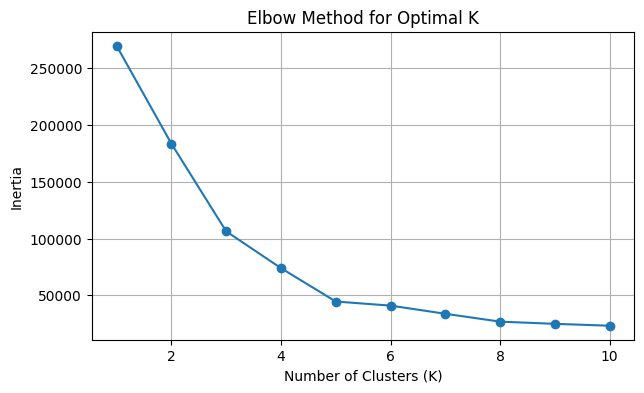

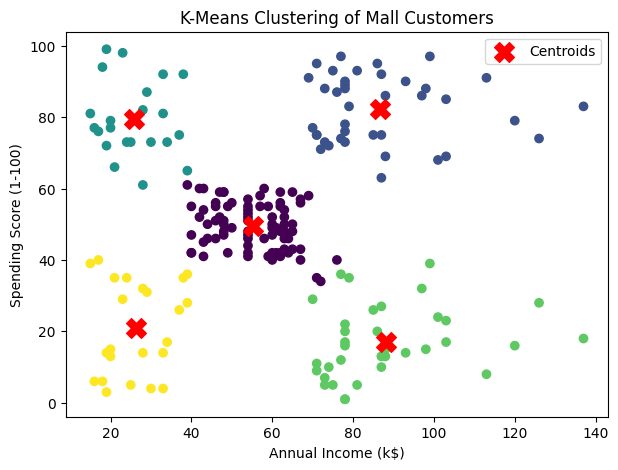

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [1]:
# Install & Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from google.colab import files

# 1. Upload Dataset
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

# 2. Select Features for Clustering
# Using Annual Income vs Spending Score (common for this dataset)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 3. Elbow Method to find optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# 4. Apply K-Means with chosen K (e.g., K = 5)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# 5. Visualize Clusters
plt.figure(figsize=(7,5))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=df['Cluster'], cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, c='red', marker='X', label='Centroids')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clustering of Mall Customers")
plt.legend()
plt.show()

# 6. Print Cluster Centers
kmeans.cluster_centers_
